# 11 — Music Generation

## Objective

In this notebook, we will generate short music clips from text prompts using MusicGen.

The practical focus will be **hard techno**.

We will explore:

- text-to-music generation
- prompt conditioning
- BPM and style descriptions
- waveform generation
- audio playback
- sample rate and duration
- prompt comparison

## Target style

We will generate short clips inspired by:

- hard techno
- industrial techno
- acid techno
- warehouse rave
- distorted kicks
- fast BPM
- dark electronic textures

In [2]:
import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)

if torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Device:", device)

PyTorch: 2.8.0
Transformers: 4.57.6
Device: mps


In [3]:
from transformers import AutoProcessor, MusicgenForConditionalGeneration

model_name = "facebook/musicgen-small"

processor = AutoProcessor.from_pretrained(model_name)

model = MusicgenForConditionalGeneration.from_pretrained(
    model_name
).to(device)

print("MusicGen loaded")

MusicGen loaded


In [4]:
prompt = (
    "Hard techno, 155 BPM, distorted kick, dark industrial atmosphere, "
    "aggressive percussion, rumbling bass, warehouse rave energy, no vocals"
)

inputs = processor(
    text=[prompt],
    padding=True,
    return_tensors="pt"
)

inputs = {k: v.to(device) for k, v in inputs.items()}

print("Prompt ready")

Prompt ready


In [5]:
with torch.no_grad():
    audio_values = model.generate(
        **inputs,
        do_sample=True,
        guidance_scale=3,
        max_new_tokens=256
    )

print("Generation complete")
print("Shape:", audio_values.shape)

Generation complete
Shape: torch.Size([1, 1, 161920])


In [6]:
import scipy.io.wavfile as wavfile
from pathlib import Path

sample_rate = model.config.audio_encoder.sampling_rate

audio = audio_values[0, 0].cpu().numpy()

output_path = Path("../outputs/musicgen_hard_techno.wav")
output_path.parent.mkdir(exist_ok=True)

wavfile.write(
    output_path,
    rate=sample_rate,
    data=audio
)

duration = len(audio) / sample_rate

print("Saved:", output_path)
print("Sample rate:", sample_rate)
print("Duration:", duration)

Saved: ../outputs/musicgen_hard_techno.wav
Sample rate: 32000
Duration: 5.06


In [7]:
from IPython.display import Audio, display

display(Audio("../outputs/musicgen_hard_techno.wav"))

## First hard techno generation

We generated a short hard techno clip from the following text prompt:

```text
Hard techno, 155 BPM, distorted kick, dark industrial atmosphere,
aggressive percussion, rumbling bass, warehouse rave energy, no vocals

In [8]:
prompts = [
    "Hard techno, 155 BPM, distorted kick, dark industrial atmosphere, aggressive percussion, rumbling bass, warehouse rave energy, no vocals",

    "Acid hard techno, 160 BPM, distorted 909 kick, aggressive acid bassline, hypnotic repetitive groove, dark underground rave, no vocals",

    "Peak-time hard techno, 158 BPM, massive kick, metallic percussion, dark synth stabs, intense energy, warehouse club atmosphere, no vocals"
]

In [9]:
from pathlib import Path
import scipy.io.wavfile as wavfile
import torch

output_dir = Path("../outputs/musicgen_variations")
output_dir.mkdir(parents=True, exist_ok=True)

sample_rate = model.config.audio_encoder.sampling_rate

for i, prompt in enumerate(prompts, start=1):

    inputs = processor(
        text=[prompt],
        padding=True,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        audio_values = model.generate(
            **inputs,
            do_sample=True,
            guidance_scale=3,
            max_new_tokens=256
        )

    audio = audio_values[0, 0].cpu().numpy()

    path = output_dir / f"hard_techno_{i}.wav"

    wavfile.write(
        path,
        rate=sample_rate,
        data=audio
    )

    print(f"Saved: {path}")

Saved: ../outputs/musicgen_variations/hard_techno_1.wav
Saved: ../outputs/musicgen_variations/hard_techno_2.wav
Saved: ../outputs/musicgen_variations/hard_techno_3.wav


In [10]:
from IPython.display import Audio, display

for i in range(1, 4):
    print(f"Variation {i}")
    display(Audio(f"../outputs/musicgen_variations/hard_techno_{i}.wav"))

Variation 1


Variation 2


Variation 3


## Prompt comparison

We generated three short hard-techno variations using different text prompts.

### Variation 1 — Industrial hard techno

Focus:

- distorted kick
- rumbling bass
- industrial atmosphere
- warehouse energy

### Variation 2 — Acid hard techno

Focus:

- 160 BPM
- distorted 909 kick
- acid bassline
- hypnotic repetitive groove

### Variation 3 — Peak-time hard techno

Focus:

- massive kick
- metallic percussion
- dark synth stabs
- intense club energy

### Observation

Changing the text prompt clearly influenced the musical character of the generated audio.

The model reacted not only to the genre label `hard techno`, but also to more specific descriptions such as:

- `acid bassline`
- `industrial atmosphere`
- `metallic percussion`
- `peak-time energy`

This demonstrates how prompt engineering can guide music generation toward different substyles while staying within the same general genre.

In [11]:
import torchaudio
from pathlib import Path

for i in range(1, 4):
    path = Path(f"../outputs/musicgen_variations/hard_techno_{i}.wav")

    waveform, sr = torchaudio.load(path)
    duration = waveform.shape[1] / sr

    print(f"Variation {i}")
    print("Sample rate:", sr)
    print("Duration:", round(duration, 2), "seconds")
    print("Shape:", waveform.shape)
    print("-" * 30)

Variation 1
Sample rate: 32000
Duration: 5.06 seconds
Shape: torch.Size([1, 161920])
------------------------------
Variation 2
Sample rate: 32000
Duration: 5.06 seconds
Shape: torch.Size([1, 161920])
------------------------------
Variation 3
Sample rate: 32000
Duration: 5.06 seconds
Shape: torch.Size([1, 161920])
------------------------------


/Users/ziyadamine/Documents/weather-audio-learning/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


/Users/ziyadamine/Documents/weather-audio-learning/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


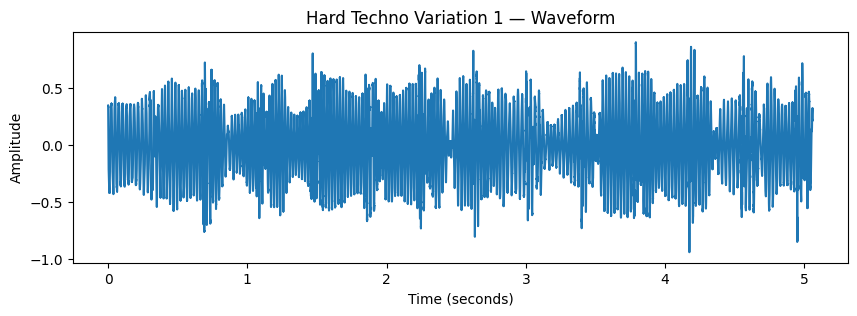

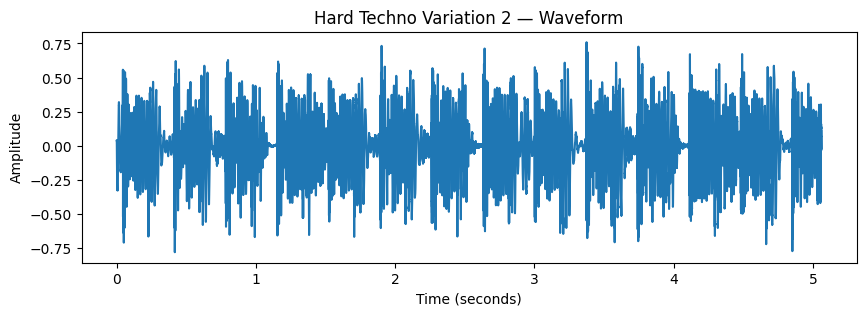

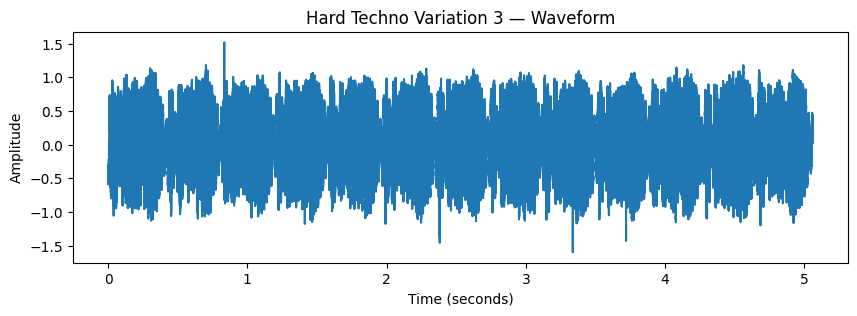

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torchaudio

for i in range(1, 4):
    path = f"../outputs/musicgen_variations/hard_techno_{i}.wav"

    waveform, sr = torchaudio.load(path)

    audio = waveform[0].numpy()
    time_axis = np.arange(len(audio)) / sr

    plt.figure(figsize=(10, 3))
    plt.plot(time_axis, audio)
    plt.title(f"Hard Techno Variation {i} — Waveform")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.show()

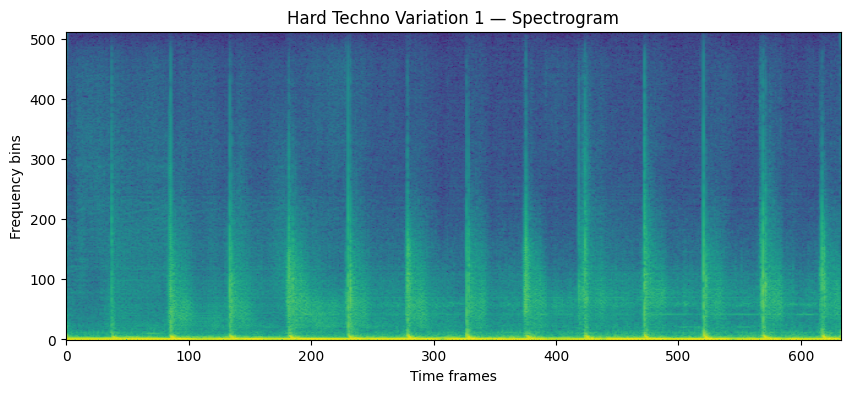

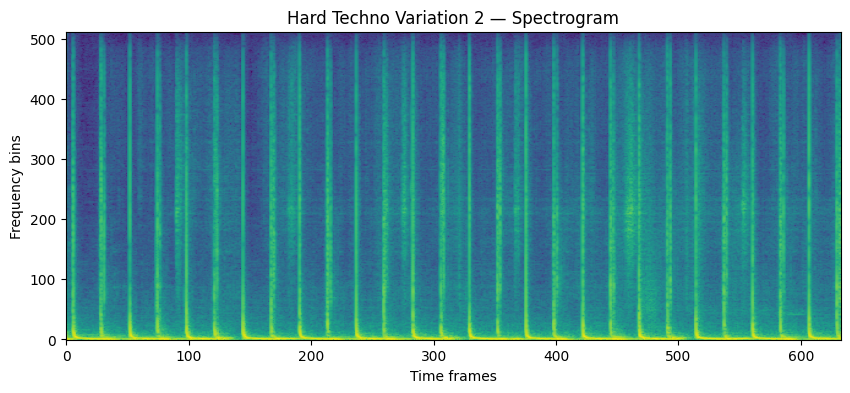

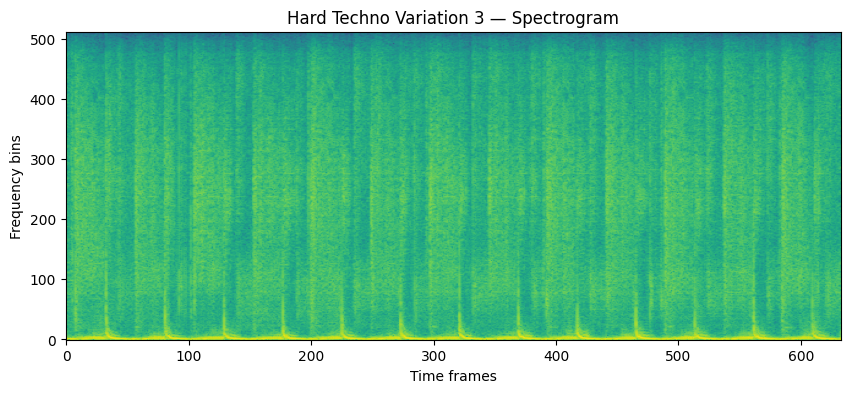

In [13]:
import matplotlib.pyplot as plt
import torch
import torchaudio

for i in range(1, 4):
    path = f"../outputs/musicgen_variations/hard_techno_{i}.wav"

    waveform, sr = torchaudio.load(path)

    spectrogram = torchaudio.transforms.Spectrogram(
        n_fft=1024,
        hop_length=256
    )(waveform)

    spectrogram_db = torchaudio.transforms.AmplitudeToDB()(
        spectrogram
    )

    plt.figure(figsize=(10, 4))
    plt.imshow(
        spectrogram_db[0].numpy(),
        origin="lower",
        aspect="auto"
    )
    plt.title(f"Hard Techno Variation {i} — Spectrogram")
    plt.xlabel("Time frames")
    plt.ylabel("Frequency bins")
    plt.show()

## Conclusion

In this notebook, we explored AI-based music generation using MusicGen.

We generated short hard-techno clips from text prompts and analyzed how prompt wording influenced the musical output.

### What we explored

- text-to-music generation
- MusicGen inference
- hard techno prompt engineering
- BPM and style conditioning
- industrial, acid, and peak-time techno variations
- audio playback
- sample rate and duration
- waveform visualization
- spectrogram visualization

### Generation pipeline

```text
Text prompt
↓
MusicGen
↓
Audio representation
↓
Decoder
↓
Generated waveform
```
### Generation pipeline
